Linear Regression on Diabetes and California Housing Dataset

In [1]:
import torch

# Check PyTorch version
print("PyTorch version:", torch.__version__)

# Check if GPU is available
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.10.0+cpu
CUDA available: False


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from scipy import stats
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
# Step 1: Load the Diabetes dataset from sklearn
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [4]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nFeature Names: {diabetes.feature_names}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nBasic Statistics:\n{df.describe().round(2)}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

DATASET OVERVIEW

Shape: (442, 11)

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Basic Statistics:
          age     sex     bmi      bp      s1      s2      s3      s4      s5  \
count  442.00  442.00  442.00  442.00  442.00  442.00  442.00  442.

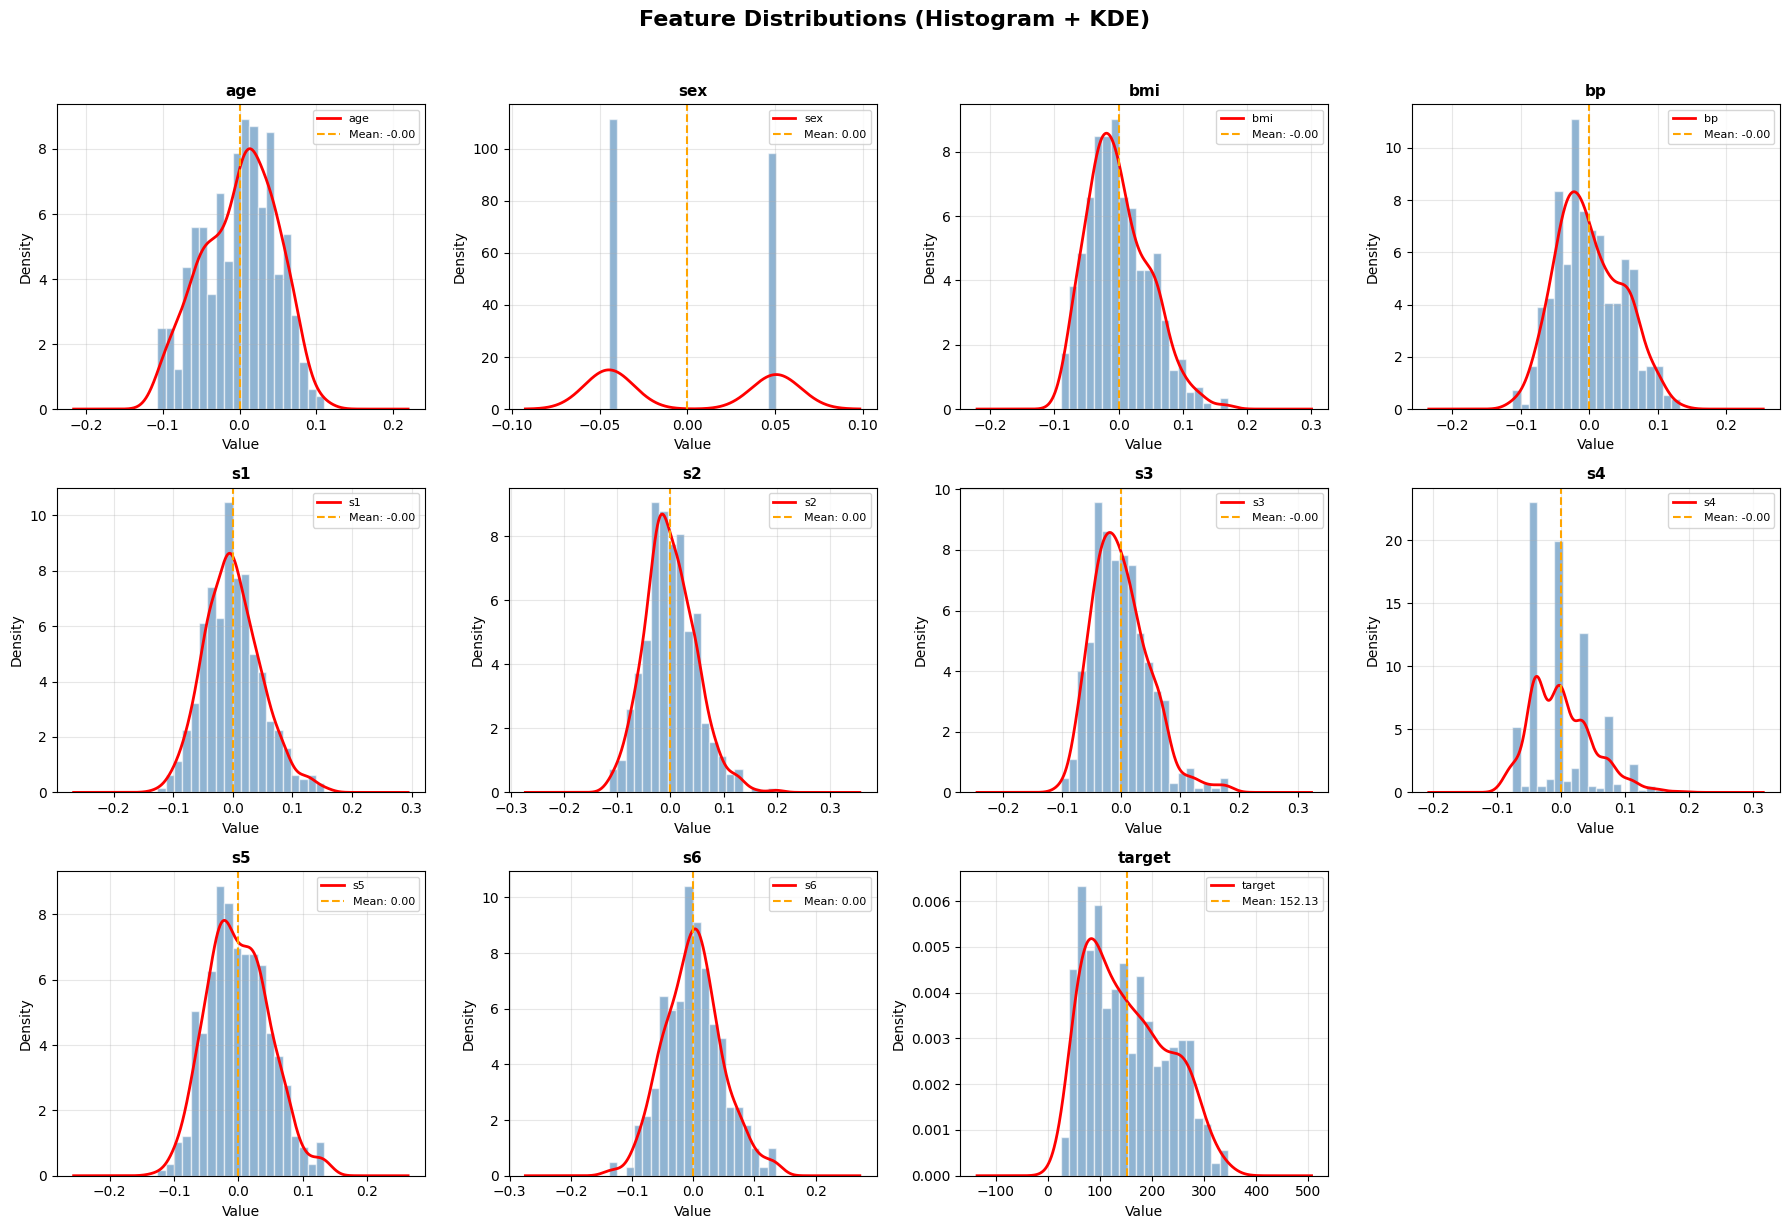

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Distributions (Histogram + KDE)',
             fontsize=16, fontweight='bold', y=1.02)

axes = axes.flatten()
features = diabetes.feature_names + ['target']

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Histogram with KDE
    df[feature].hist(bins=20, ax=ax, alpha=0.6,
                     color='steelblue', edgecolor='white', density=True)

    # Overlay KDE
    df[feature].plot.kde(ax=ax, color='red', linewidth=2)

    ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

    # Add mean and std annotations
    mean_val = df[feature].mean()
    std_val  = df[feature].std()
    ax.axvline(mean_val, color='orange',
               linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

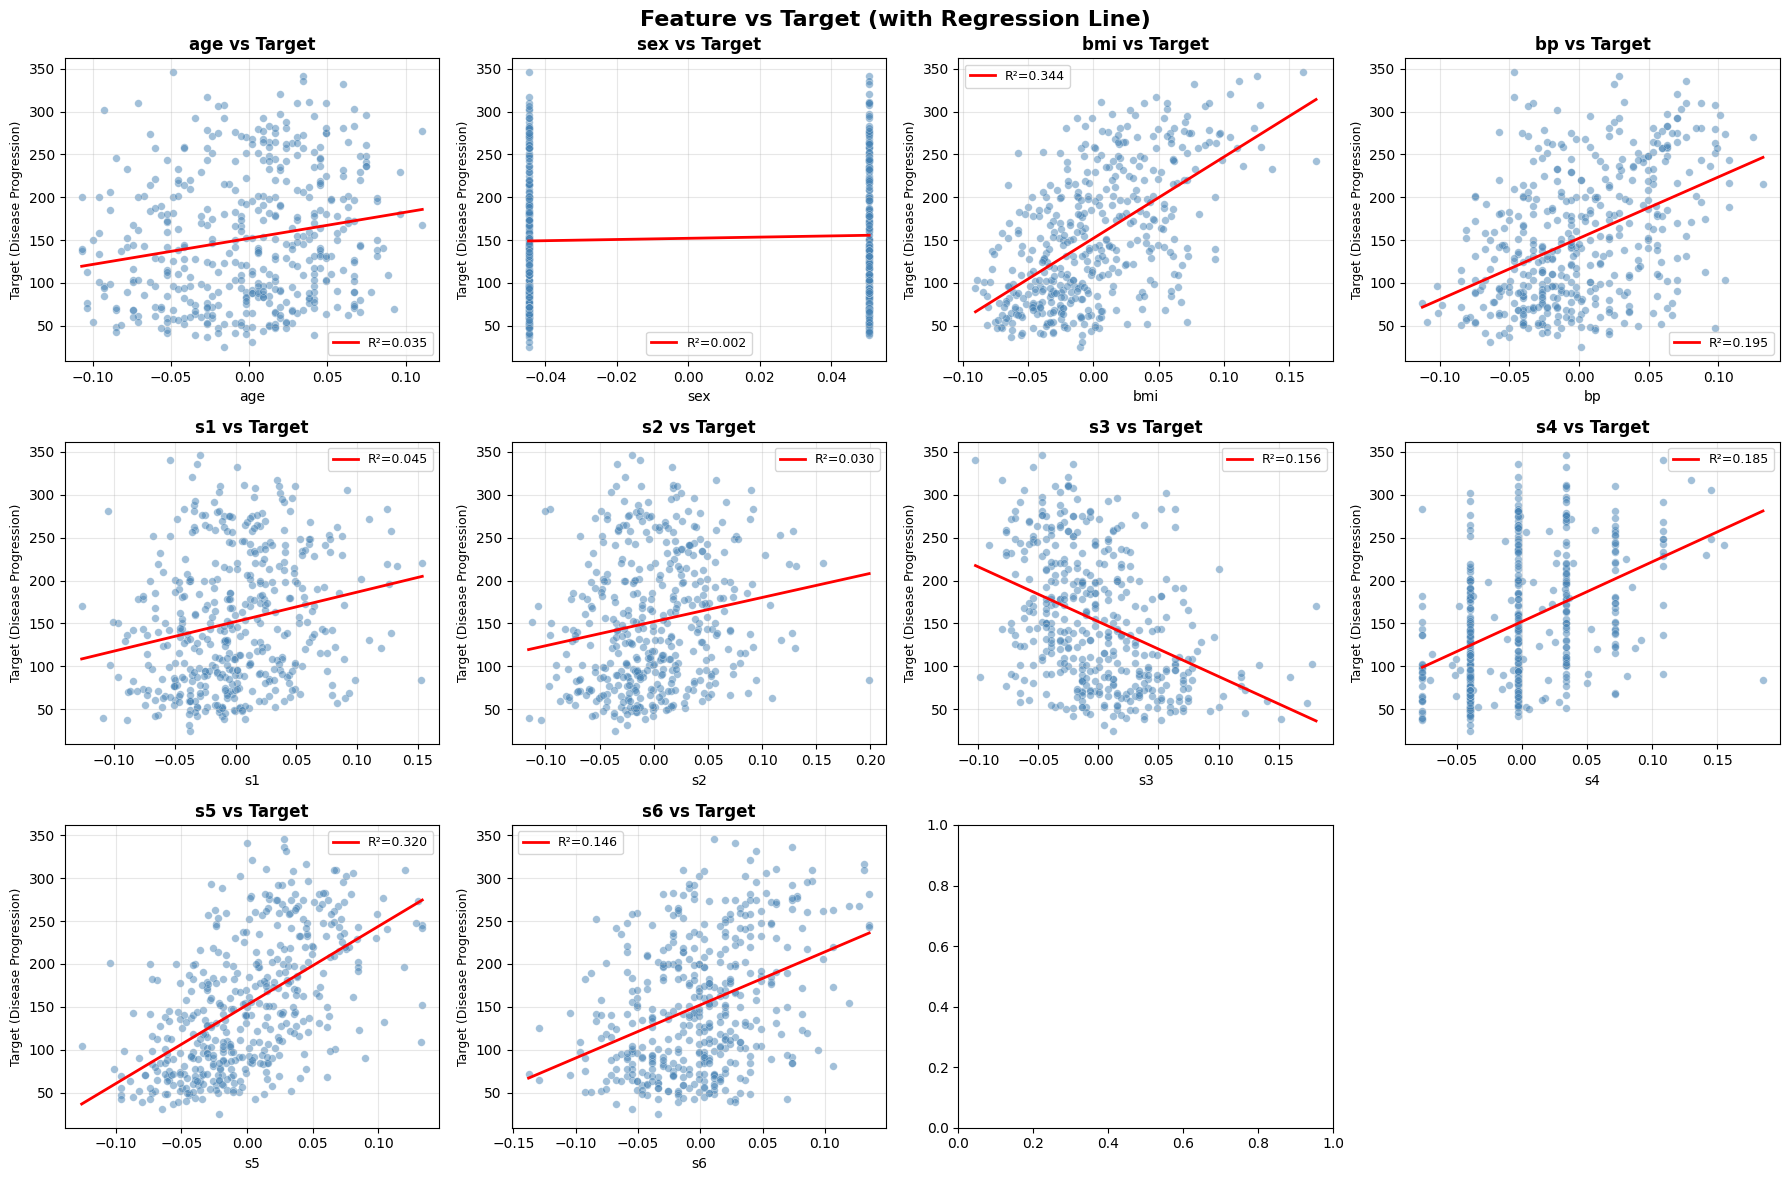

In [6]:
# ============================================================
# Step 3: Scatter Plots - Each Feature vs Target
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature vs Target (with Regression Line)',
             fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, feature in enumerate(diabetes.feature_names):
    ax = axes[idx]

    # Scatter plot
    ax.scatter(df[feature], df['target'],
               alpha=0.5, color='steelblue',
               edgecolors='white', linewidth=0.3, s=30)

    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df[feature], df['target']
    )
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linewidth=2, label=f'R²={r_value**2:.3f}')

    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Target (Disease Progression)', fontsize=9)
    ax.set_title(f'{feature} vs Target', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

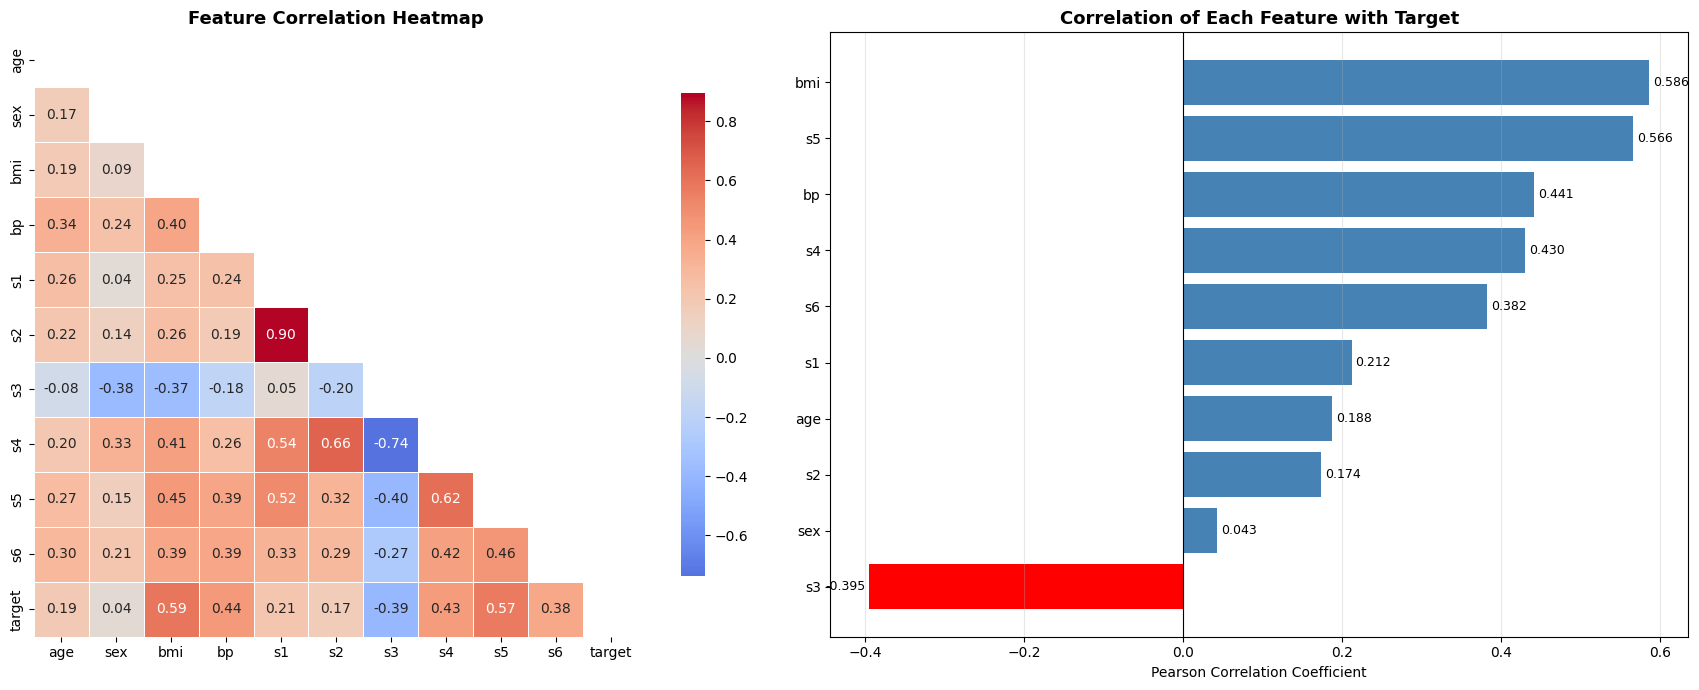

In [7]:
# ============================================================
# Step 4: Correlation Heatmap
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Full Correlation Matrix ---
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(
    corr_matrix,
    ax=axes[0],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title('Feature Correlation Heatmap',
                   fontweight='bold', fontsize=13)

# --- Correlation with Target Only ---
target_corr = df.corr()[['target']].drop('target').sort_values(
    'target', ascending=True
)

colors = ['red' if x < 0 else 'steelblue' for x in target_corr['target']]
bars = axes[1].barh(target_corr.index, target_corr['target'], color=colors)

# Add value labels on bars
for bar, val in zip(bars, target_corr['target']):
    axes[1].text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation of Each Feature with Target',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

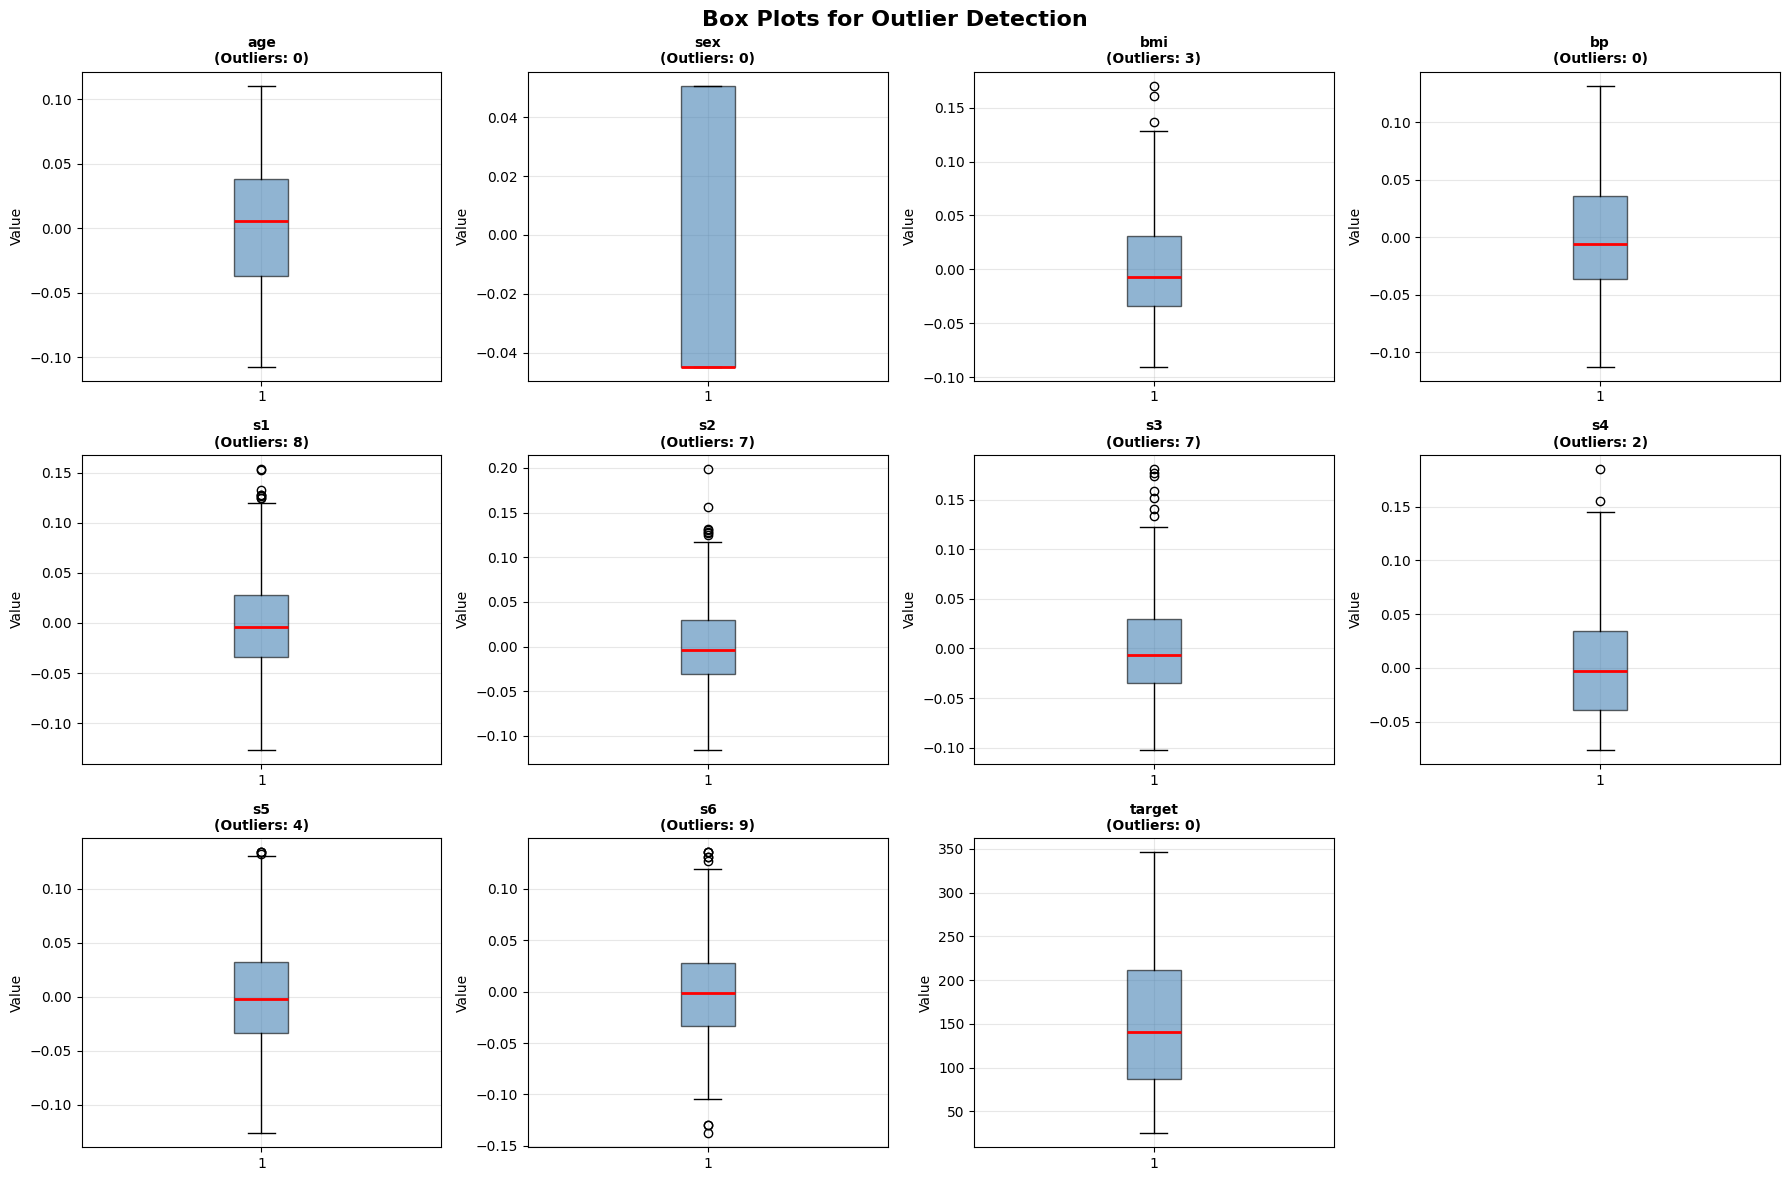

In [8]:
# ============================================================
# Step 5: Box Plots (Outlier Detection)
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Box Plots for Outlier Detection',
             fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]

    bp = ax.boxplot(df[feature], patch_artist=True,
                    medianprops=dict(color='red', linewidth=2))

    # Color the box
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)

    # Count outliers using IQR
    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5 * IQR) |
                  (df[feature] > Q3 + 1.5 * IQR)]

    ax.set_title(f'{feature}\n(Outliers: {len(outliers)})',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

Top 5 Correlated Features: ['bmi', 's5', 'bp', 's4', 's3']


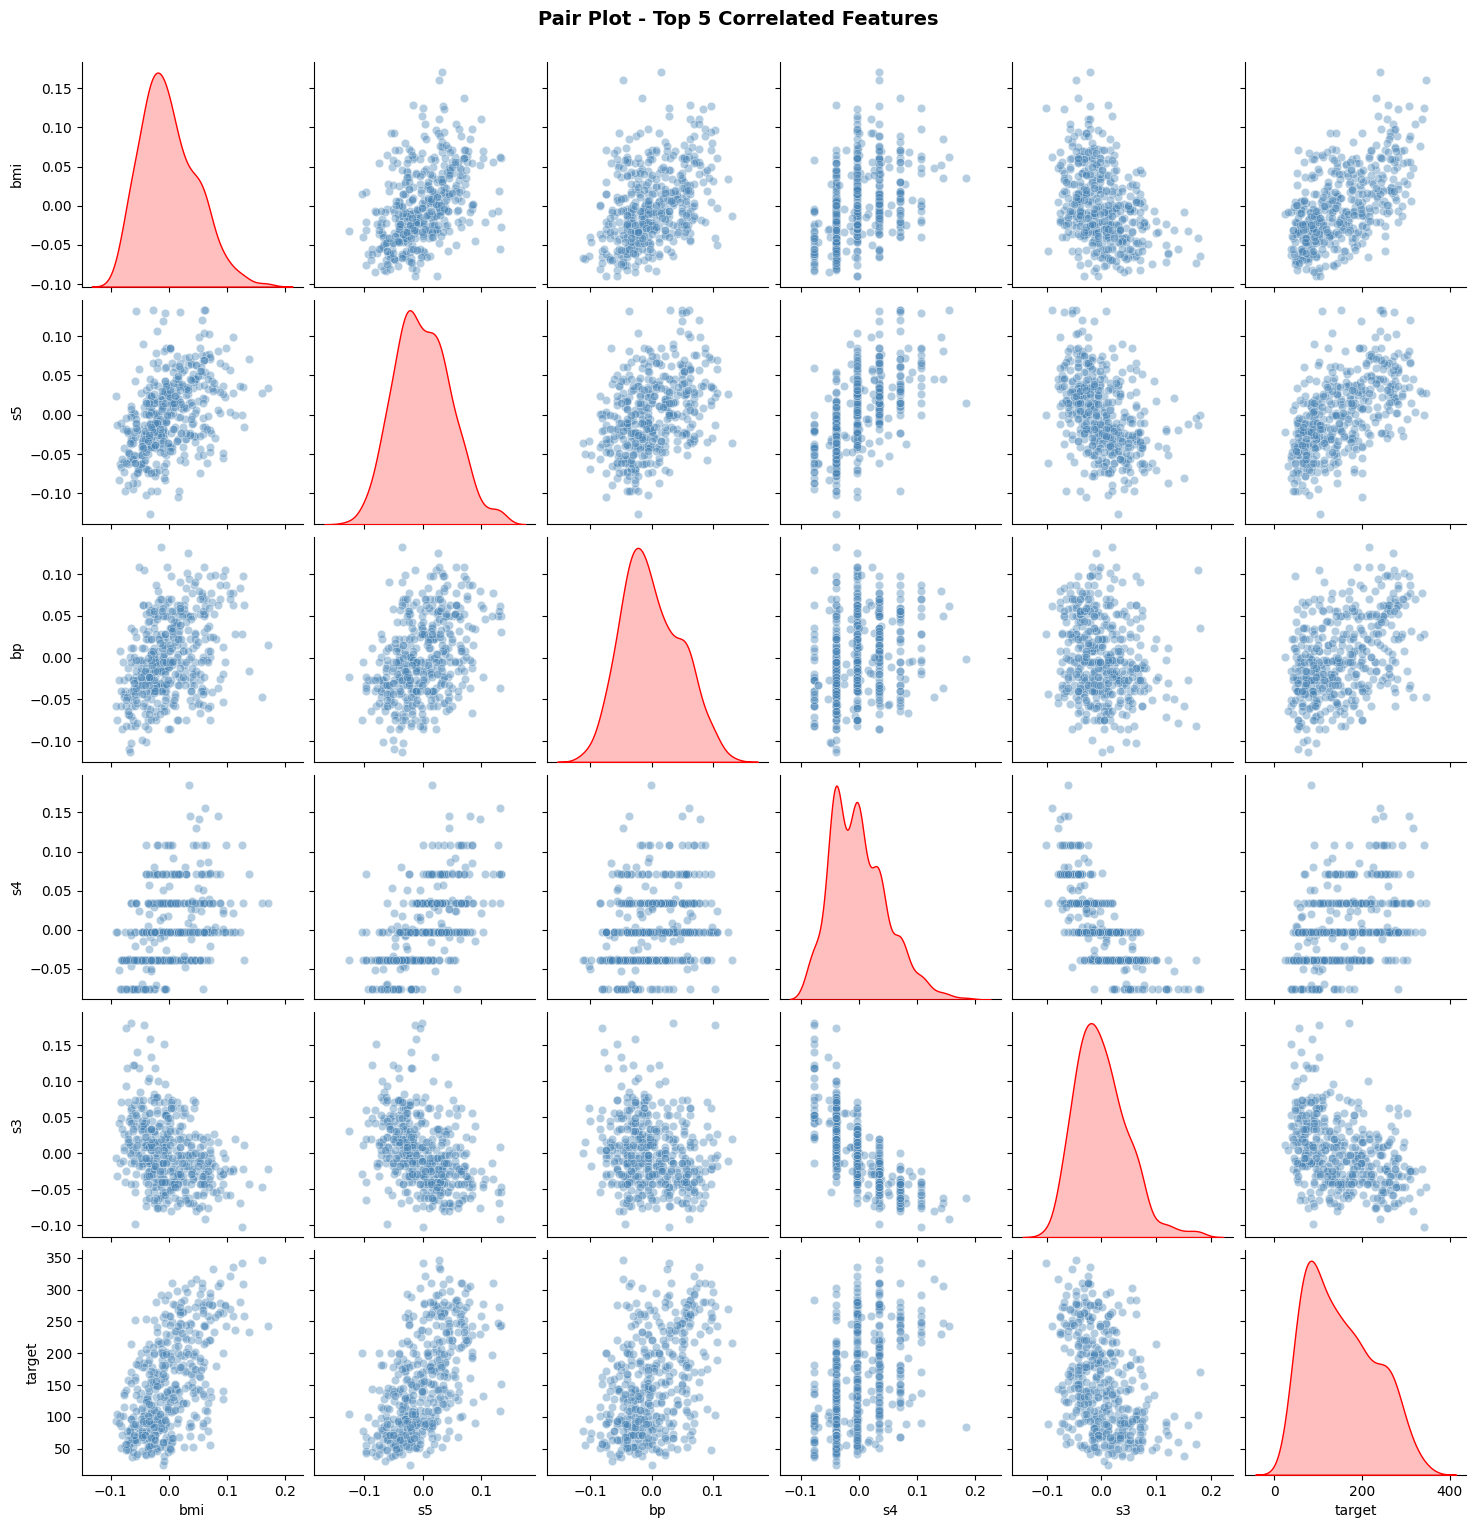

In [9]:
# ============================================================
# Step 6: Pair Plot (Top Correlated Features)
# ============================================================

# Select top 5 features most correlated with target
top_features = (df.corr()['target']
                  .drop('target')
                  .abs()
                  .sort_values(ascending=False)
                  .head(5)
                  .index
                  .tolist())

print(f"Top 5 Correlated Features: {top_features}")

pair_df = df[top_features + ['target']]

pair_plot = sns.pairplot(
    pair_df,
    diag_kind='kde',         # KDE on diagonal
    plot_kws={'alpha': 0.4, 'color': 'steelblue'},
    diag_kws={'color': 'red', 'fill': True}
)
pair_plot.figure.suptitle(
    'Pair Plot - Top 5 Correlated Features',
    y=1.02, fontsize=14, fontweight='bold'
)

plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

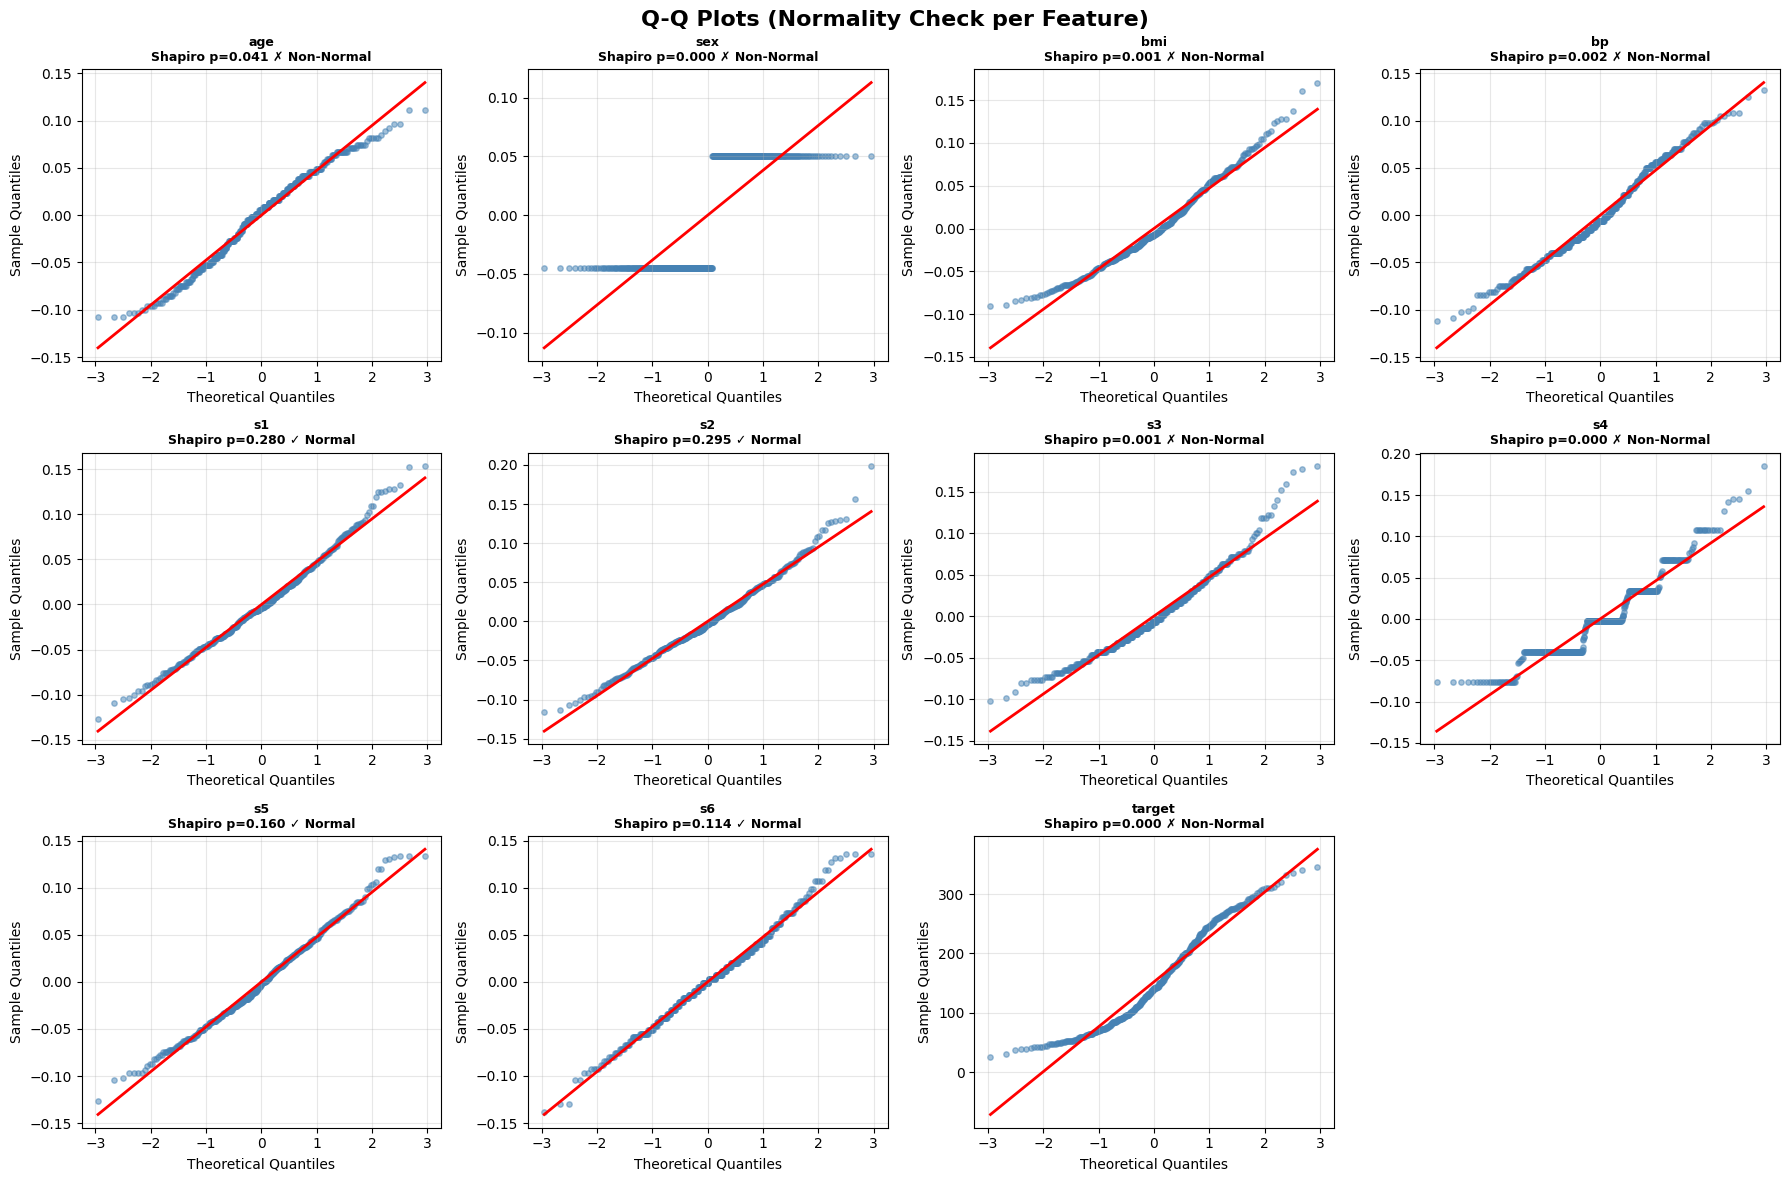

In [10]:
# ============================================================
# Step 7: Q-Q Plots (Normality Check)
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Q-Q Plots (Normality Check per Feature)',
             fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Q-Q plot using scipy
    (osm, osr), (slope, intercept, r) = stats.probplot(df[feature])

    ax.scatter(osm, osr, alpha=0.5, color='steelblue', s=15)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color='red', linewidth=2)

    # Shapiro-Wilk test for normality (on sample for speed)
    sample = df[feature].sample(min(200, len(df)), random_state=42)
    stat, p_val = stats.shapiro(sample)

    ax.set_title(
        f'{feature}\nShapiro p={p_val:.3f} '
        f'{"✓ Normal" if p_val > 0.05 else "✗ Non-Normal"}',
        fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('qqplots_normality.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
selected_features = ['bmi', 's5', 'bp', 's4', 's3', 's6']

X = df[selected_features].values   # only selected columns
y = df['target'].values

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42          # 70% train, 30% temp
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42 # 15% val, 15% test
)
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 309 | Val: 66 | Test: 67


In [13]:
scaler_X = StandardScaler()
X_train  = scaler_X.fit_transform(X_train)    # fit on train only
X_val    = scaler_X.transform(X_val)
X_test   = scaler_X.transform(X_test)

y_mean = y_train.mean()
y_std  = y_train.std()

y_train_s = (y_train - y_mean) / y_std
y_val_s   = (y_val   - y_mean) / y_std
y_test_s  = (y_test  - y_mean) / y_std

print(f"y_train range: [{y_train.min():.1f}, {y_train.max():.1f}]  →  "
      f"scaled: [{y_train_s.min():.2f}, {y_train_s.max():.2f}]")


y_train range: [25.0, 346.0]  →  scaled: [-1.64, 2.45]


In [14]:
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t  = to_tensor(X_train)
y_train_t  = to_tensor(y_train_s).unsqueeze(1)

X_val_t    = to_tensor(X_val)
y_val_t    = to_tensor(y_val_s).unsqueeze(1)

X_test_t   = to_tensor(X_test)
y_test_t   = to_tensor(y_test_s).unsqueeze(1)


In [15]:
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32, shuffle=True
)

Loading Data

Epoch [   0/2000] Train: 1.26561 | Val: 0.83559 | LR: 0.010000 | Patience: 0/300
Epoch [ 300/2000] Train: 0.50461 | Val: 0.39596 | LR: 0.002500 | Patience: 134/300

⏹  Early stopping at epoch 466

✅ Best model loaded — Val Loss: 0.393058

── Test Metrics (original scale) ──────────────────────
  MSE  : 3293.4600
  RMSE : 57.3887  ← avg error in same unit as y
  MAE  : 46.6527
  R²   : 0.4200   ← closer to 1.0 is better

── Learned Weights ─────────────────────────────────────
   bmi: +0.3608  +███████
    s5: +0.2545  +█████
    bp: +0.1988  +███
    s4: -0.0884  -█
    s3: -0.2041  -████
    s6: +0.0294  +
  bias: +0.0036


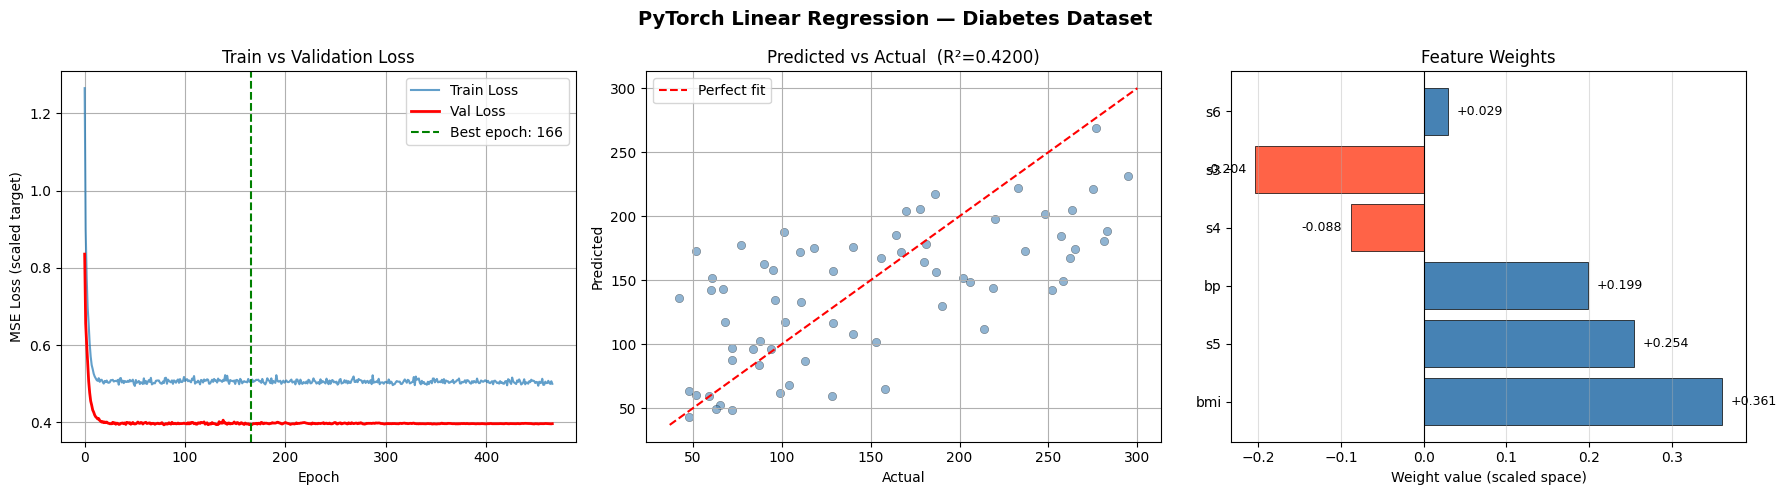

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Linear(in_features=6, out_features=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)

epochs              = 2000
early_stop_patience = 300

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100
)
train_losses = []
val_losses   = []

best_val_loss    = float("inf")
best_weights     = None
patience_counter = 0

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        preds = model(batch_X)
        loss  = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Validation phase ───────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t.to(device))
        val_loss  = criterion(val_preds, y_val_t.to(device)).item()
    val_losses.append(val_loss)

    # ── LR Scheduler ──────────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ── Save Best Model ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    # ── Early Stopping ─────────────────────────────────────────────────────────
    if patience_counter >= early_stop_patience:
        print(f"\n Early stopping at epoch {epoch}")
        break

    # ── Logging ────────────────────────────────────────────────────────────────
    if epoch % 300 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:>4}/{epochs}] "
              f"Train: {train_loss:.5f} | "
              f"Val: {val_loss:.5f} | "
              f"LR: {lr_now:.6f} | "
              f"Patience: {patience_counter}/{early_stop_patience}")

# ── Load Best Weights ──────────────────────────────────────────────────────────
model.load_state_dict(best_weights)
print(f"\n Best model loaded — Val Loss: {best_val_loss:.6f}")

# ── Test Evaluation ────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    test_pred_scaled = model(X_test_t.to(device)).cpu().numpy().flatten()

test_pred_orig = test_pred_scaled * y_std + y_mean

# Metrics in original scale
mse  = mean_squared_error(y_test, test_pred_orig)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, test_pred_orig)
r2   = r2_score(y_test, test_pred_orig)

print("\n── Test Metrics (original scale) ──────────────────────")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}  ← avg error in same unit as y")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}   ← closer to 1.0 is better")

weights = model.weight.detach().cpu().numpy().flatten()
bias    = model.bias.detach().cpu().item()

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss curves
axes[0].plot(train_losses, label="Train Loss", alpha=0.7)
axes[0].plot(val_losses,   label="Val Loss",   color="red", linewidth=2)
axes[0].axvline(
    np.argmin(val_losses),
    color="green", linestyle="--",
    label=f"Best epoch: {np.argmin(val_losses)}"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (scaled target)")
axes[0].set_title("Train vs Validation Loss")
axes[0].legend()
axes[0].grid(True)

# 2. Predicted vs Actual
axes[1].scatter(y_test, test_pred_orig, alpha=0.6, color="steelblue", edgecolors="k", linewidths=0.3)
lo = min(y_test.min(), test_pred_orig.min()) - 5
hi = max(y_test.max(), test_pred_orig.max()) + 5
axes[1].plot([lo, hi], [lo, hi], "r--", label="Perfect fit")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Predicted vs Actual  (R²={r2:.4f})")
axes[1].legend()
axes[1].grid(True)

# 3. Feature importance (learned weights)
colors = ["steelblue" if w > 0 else "tomato" for w in weights]
bars = axes[2].barh(selected_features, weights, color=colors, edgecolor="k", linewidth=0.5)
axes[2].axvline(0, color="black", linewidth=0.8)
for bar, w in zip(bars, weights):
    axes[2].text(
        w + (0.01 if w >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{w:+.3f}",
        va="center",
        ha="left" if w >= 0 else "right",
        fontsize=9
    )
axes[2].set_xlabel("Weight value (scaled space)")
axes[2].set_title("Feature Weights")
axes[2].grid(True, axis="x", alpha=0.4)

plt.suptitle("PyTorch Linear Regression — Diabetes Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Load
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target
df['lat_lon'] = df['Latitude'] * df['Longitude']
df = df.drop(columns=["Latitude", "Longitude"])
df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,target,lat_lon
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,4.526,-4630.0724
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,3.585,-4627.2492
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,3.521,-4626.7840
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,3.413,-4627.1625
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,3.422,-4627.1625
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,0.781,-4780.6332
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,0.771,-4786.5829
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,0.923,-4779.7046
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,0.847,-4783.6476


In [19]:
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.describe()


Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
target        0
lat_lon       0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,target,lat_lon
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,2.068558,-4264.448003
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,1.153956,323.904337
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,0.149990,-5207.673000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,1.196000,-4601.026500
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,1.797000,-4060.278900
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,2.647250,-4004.349775
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,5.000010,-3753.968400


In [20]:
selected_features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','lat_lon']
X = df[selected_features].values
y = df['target'].values
y.shape

(20640,)

In [30]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

scaler_X = StandardScaler()
X_train  = scaler_X.fit_transform(X_train)
X_val    = scaler_X.transform(X_val)
X_test   = scaler_X.transform(X_test)

y_mean = y_train.mean()
y_std  = y_train.std()

y_train_s = (y_train - y_mean) / y_std
y_val_s   = (y_val   - y_mean) / y_std
y_test_s  = (y_test  - y_mean) / y_std

print(f"y_train range: [{y_train.min():.1f}, {y_train.max():.1f}]  →  "
      f"scaled: [{y_train_s.min():.2f}, {y_train_s.max():.2f}]")

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t  = to_tensor(X_train)
y_train_t  = to_tensor(y_train_s).unsqueeze(1)

X_val_t    = to_tensor(X_val)
y_val_t    = to_tensor(y_val_s).unsqueeze(1)

X_test_t   = to_tensor(X_test)
y_test_t   = to_tensor(y_test_s).unsqueeze(1)


train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32, shuffle=True
)

Train: (14448, 7) | Val: (3096, 7) | Test: (3096, 7)
y_train range: [0.1, 5.0]  →  scaled: [-1.66, 2.53]


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'target', 'lat_lon'],
      dtype='object')


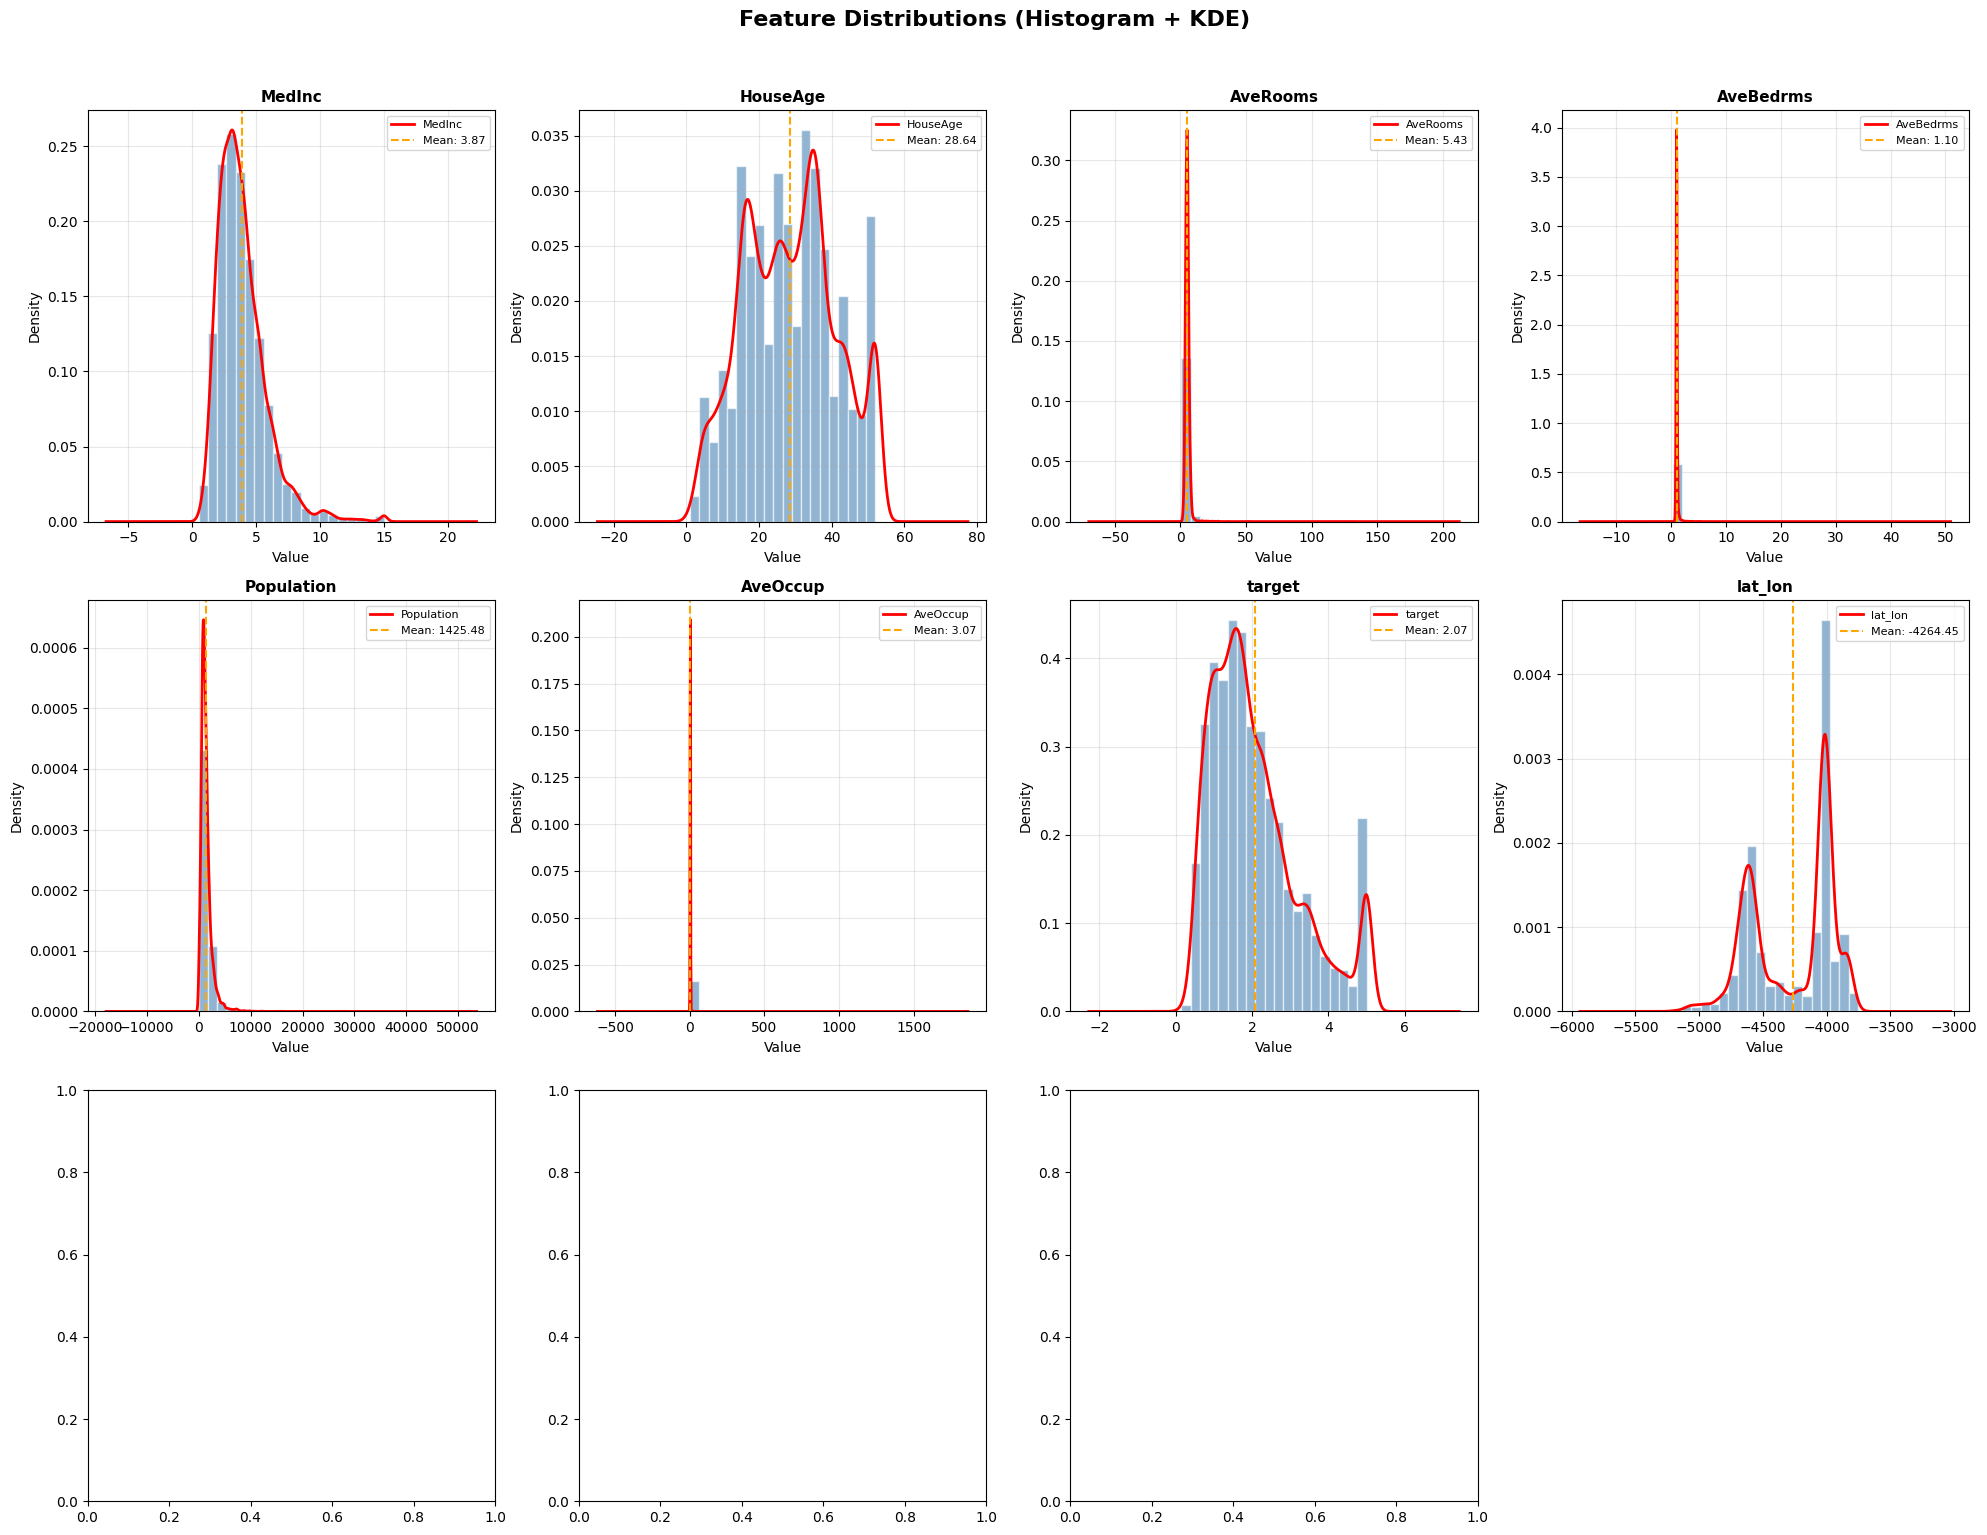

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Feature Distributions (Histogram + KDE)',
             fontsize=16, fontweight='bold', y=1.02)

axes = axes.flatten()
features = df.columns
print(features)
for idx, feature in enumerate(features):
  ax = axes[idx]

  # Histogram with KDE
  df[feature].hist(bins=20, ax=ax, alpha=0.6,
                    color='steelblue', edgecolor='white', density=True)

  # Overlay KDE
  df[feature].plot.kde(ax=ax, color='red', linewidth=2)

  ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
  ax.set_xlabel('Value')
  ax.set_ylabel('Density')
  ax.grid(True, alpha=0.3)

  # Add mean and std annotations
  mean_val = df[feature].mean()
  std_val  = df[feature].std()
  ax.axvline(mean_val, color='orange',
              linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
  ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

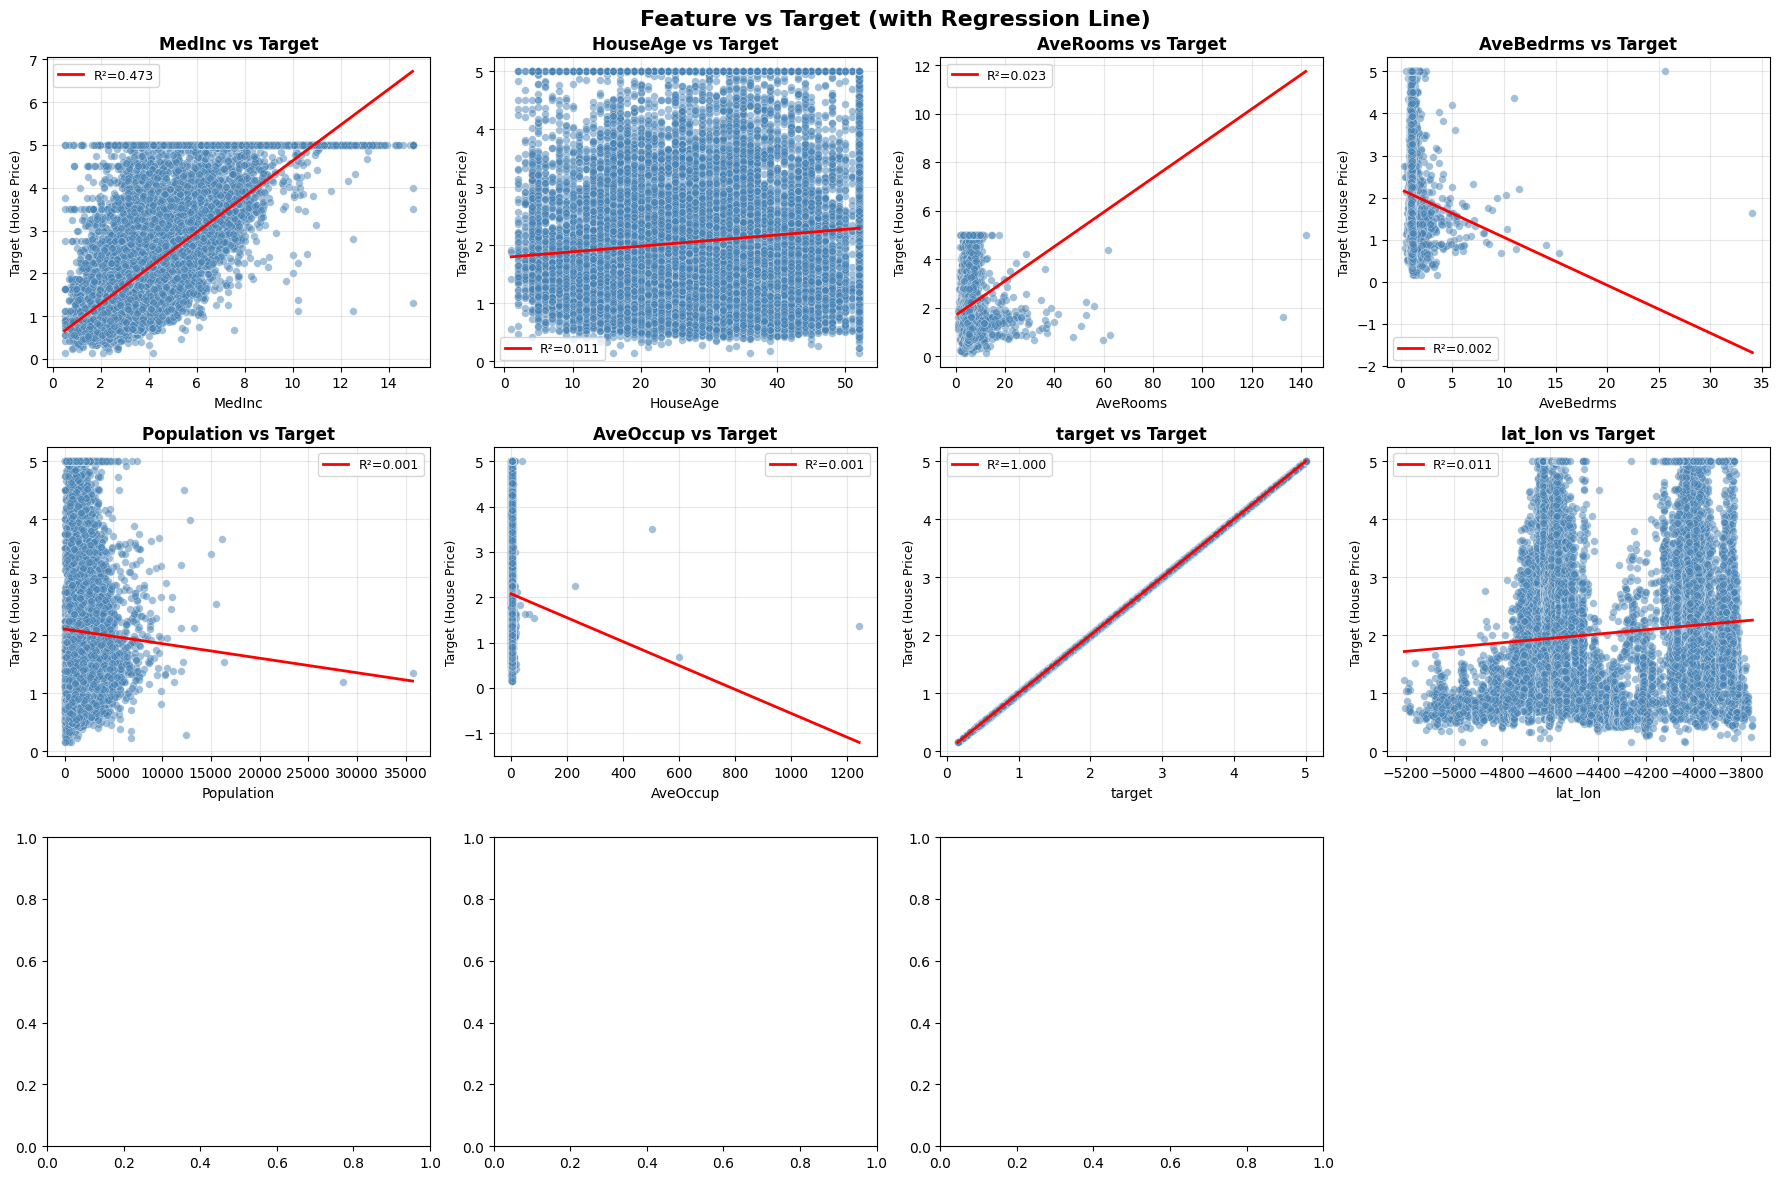

In [32]:

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature vs Target (with Regression Line)',
             fontsize=16, fontweight='bold')

axes = axes.flatten()
features = df.columns

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Scatter plot
    ax.scatter(df[feature], df['target'],
               alpha=0.5, color='steelblue',
               edgecolors='white', linewidth=0.3, s=30)

    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df[feature], df['target']
    )
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linewidth=2, label=f'R²={r_value**2:.3f}')

    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Target (House Price)', fontsize=9)
    ax.set_title(f'{feature} vs Target', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

Epoch [   0/3000] Train: 0.70163 | Val: 0.47332 | LR: 0.010000 | Patience: 0/1000
Epoch [ 300/3000] Train: 0.46479 | Val: 0.46931 | LR: 0.005000 | Patience: 136/1000
Epoch [ 600/3000] Train: 0.45708 | Val: 0.46734 | LR: 0.000625 | Patience: 436/1000
Epoch [ 900/3000] Train: 0.45683 | Val: 0.46734 | LR: 0.000078 | Patience: 736/1000

⏹  Early stopping at epoch 1164

✅ Best model loaded — Val Loss: 0.463082

── Test Metrics (original scale) ──────────────────────
  MSE  : 0.5963
  RMSE : 0.7722  ← avg error in same unit as y
  MAE  : 0.5646
  R²   : 0.5491   ← closer to 1.0 is better

── Learned Weights ─────────────────────────────────────
  MedInc: +0.8546  +█████████████████
  HouseAge: +0.1851  +███
  AveRooms: -0.4405  -████████
  AveBedrms: +0.3989  +███████
  Population: +0.0403  +
  AveOccup: -0.2169  -████
  lat_lon: +0.0489  +
  bias: -0.0040


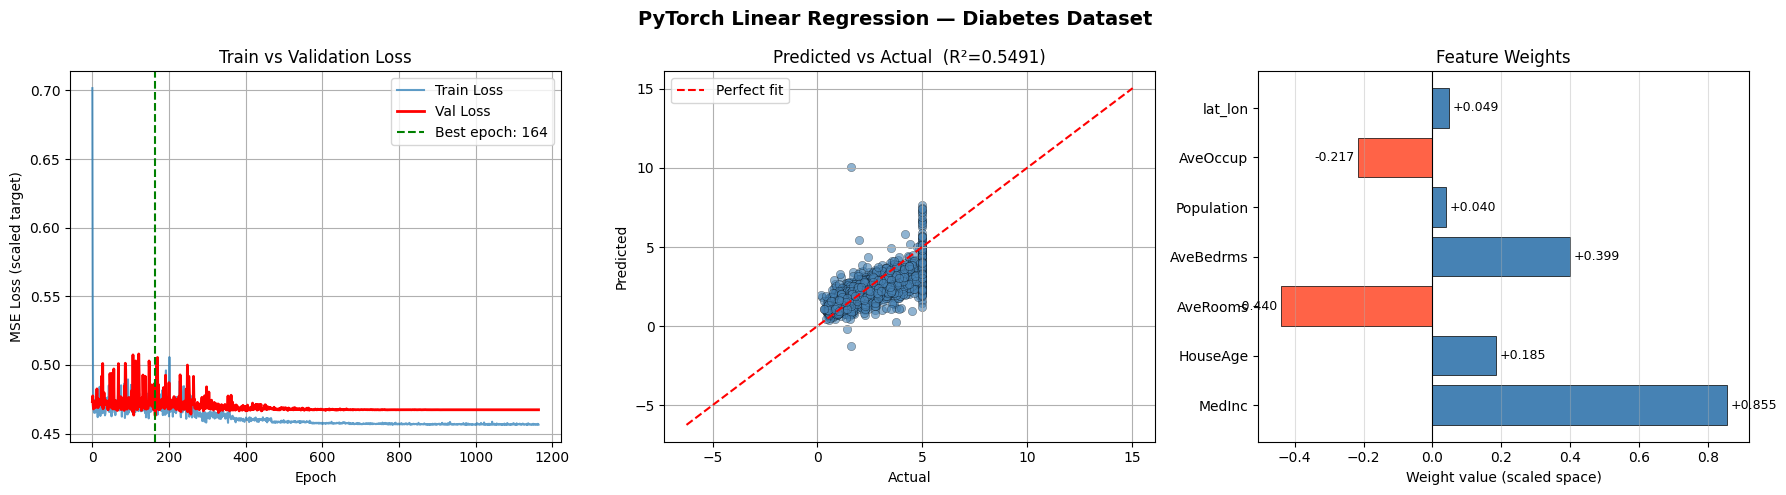

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Linear(in_features=7, out_features=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)

epochs              = 3000
early_stop_patience = 1000

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100
)
train_losses = []
val_losses   = []

best_val_loss    = float("inf")
best_weights     = None
patience_counter = 0

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        preds = model(batch_X)
        loss  = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Validation phase ───────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t.to(device))
        val_loss  = criterion(val_preds, y_val_t.to(device)).item()
    val_losses.append(val_loss)

    # ── LR Scheduler ──────────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ── Save Best Model ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    # ── Early Stopping ─────────────────────────────────────────────────────────
    if patience_counter >= early_stop_patience:
        print(f"\n  Early stopping at epoch {epoch}")
        break

    # ── Logging ────────────────────────────────────────────────────────────────
    if epoch % 300 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:>4}/{epochs}] "
              f"Train: {train_loss:.5f} | "
              f"Val: {val_loss:.5f} | "
              f"LR: {lr_now:.6f} | "
              f"Patience: {patience_counter}/{early_stop_patience}")

# ── Load Best Weights ──────────────────────────────────────────────────────────
model.load_state_dict(best_weights)
print(f"\n Best model loaded — Val Loss: {best_val_loss:.6f}")

# ── Test Evaluation ────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    test_pred_scaled = model(X_test_t.to(device)).cpu().numpy().flatten()

test_pred_orig = test_pred_scaled * y_std + y_mean

# Metrics in original scale
mse  = mean_squared_error(y_test, test_pred_orig)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, test_pred_orig)
r2   = r2_score(y_test, test_pred_orig)

print("\n── Test Metrics (original scale) ──────────────────────")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}  ← avg error in same unit as y")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}   ← closer to 1.0 is better")

weights = model.weight.detach().cpu().numpy().flatten()
bias    = model.bias.detach().cpu().item()

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss curves
axes[0].plot(train_losses, label="Train Loss", alpha=0.7)
axes[0].plot(val_losses,   label="Val Loss",   color="red", linewidth=2)
axes[0].axvline(
    np.argmin(val_losses),
    color="green", linestyle="--",
    label=f"Best epoch: {np.argmin(val_losses)}"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (scaled target)")
axes[0].set_title("Train vs Validation Loss")
axes[0].legend()
axes[0].grid(True)

# 2. Predicted vs Actual
axes[1].scatter(y_test, test_pred_orig, alpha=0.6, color="steelblue", edgecolors="k", linewidths=0.3)
lo = min(y_test.min(), test_pred_orig.min()) - 5
hi = max(y_test.max(), test_pred_orig.max()) + 5
axes[1].plot([lo, hi], [lo, hi], "r--", label="Perfect fit")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Predicted vs Actual  (R²={r2:.4f})")
axes[1].legend()
axes[1].grid(True)

# 3. Feature importance (learned weights)
colors = ["steelblue" if w > 0 else "tomato" for w in weights]
bars = axes[2].barh(selected_features, weights, color=colors, edgecolor="k", linewidth=0.5)
axes[2].axvline(0, color="black", linewidth=0.8)
for bar, w in zip(bars, weights):
    axes[2].text(
        w + (0.01 if w >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{w:+.3f}",
        va="center",
        ha="left" if w >= 0 else "right",
        fontsize=9
    )
axes[2].set_xlabel("Weight value (scaled space)")
axes[2].set_title("Feature Weights")
axes[2].grid(True, axis="x", alpha=0.4)

plt.suptitle("PyTorch Linear Regression — Diabetes Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()